# Кредитный скоринг — версия 2

Продолжение `credit_scoring_v1`. Сырую выгрузку, чистку и сплит **не повторяем**:
берём готовые файлы из `data/splits/`.

| Что добавляем | Зачем |
|---------------|--------|
| Новые признаки (отношения и агрегаты по строке) | Модель видит нагрузку, стаж, внешние скоры в более удобном виде |
| Пропуски, One-Hot / Ordinal и scaler | Как в v1: до отбора, fit только на train; IV и F-score смотрим уже после |
| IV и F-score, объединение двух топов | Однофакторный отбор: оставляем признаки, которые сами по себе связаны с дефолтом |
| Логрег + KNN + Random Forest, сетка через Optuna | Сравниваем несколько моделей на одних и тех же `*_stage_2` признаках |
| Порог по лучшей модели | Как в v1: Gini не зависит от порога, после порога смотрим F1 |

**Главная метрика ранжирования:** Gini. **После порога:** F1 по дефолту.


## 0. Импорты и настройки

`RANDOM_STATE` и `SAMPLE_SIZE` те же, что в v1 — сэмпл train совпадёт.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import optuna
from optuna.samplers import GridSampler

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from optbinning import BinningProcess
from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from IPython.display import display

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

RANDOM_STATE = 42
SAMPLE_SIZE = 50_000
ONEHOT_MAX_UNIQUE = 15

# сколько брать из топа IV и из топа F-score (один гиперпараметр, проверяем на val)
TOP_N_OPTIONS = [20, 35, 50]

PROJECT_DIR = Path('.').resolve()
SPLITS_DIR = PROJECT_DIR / 'data' / 'splits'

np.random.seed(RANDOM_STATE)
print('Проект:', PROJECT_DIR)
print('Сплиты:', SPLITS_DIR)


Проект: C:\Users\user\Desktop\ПШНТ\проект\code 0
Сплиты: C:\Users\user\Desktop\ПШНТ\проект\code 0\data\splits


In [2]:
# pip install optbinning

In [3]:
def gini_score(y_true, y_proba) -> float:
    """Gini = 2 * ROC-AUC - 1."""
    return 2 * roc_auc_score(y_true, y_proba) - 1


def classification_at_threshold(y_true, y_proba, threshold: float) -> dict:
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'threshold': threshold,
        'F1': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }


## 1. Загрузка сплитов и сэмпл train

Те же файлы, что сохранила v1. Сэмплируем только train.


In [4]:
df_train = pd.read_csv(SPLITS_DIR / 'train.csv')
df_val = pd.read_csv(SPLITS_DIR / 'val.csv')
df_test = pd.read_csv(SPLITS_DIR / 'test.csv')
df_late = pd.read_csv(SPLITS_DIR / 'late_test.csv')

print('Загружено из data/splits/:')
for name, part in [('train', df_train), ('val', df_val), ('test', df_test), ('late_test', df_late)]:
    print(f'  {name:10s} {part.shape[0]:7,} × {part.shape[1]}')


Загружено из data/splits/:
  train      180,976 × 87
  val         25,850 × 87
  test        25,851 × 87
  late_test   25,853 × 87


In [5]:
df_train_full = df_train.copy()

if SAMPLE_SIZE < len(df_train_full):
    df_train, _ = train_test_split(
        df_train_full,
        train_size=SAMPLE_SIZE,
        stratify=df_train_full['target'],
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    df_train = df_train.reset_index(drop=True)

print(f'train полный:  {len(df_train_full):,}')
print(f'train сэмпл:   {len(df_train):,}')
print(f'доля дефолтов: полный {df_train_full["target"].mean():.3%} | сэмпл {df_train["target"].mean():.3%}')


train полный:  180,976
train сэмпл:   50,000
доля дефолтов: полный 8.086% | сэмпл 8.086%



train сэмпл:   50,000
доля дефолтов: полный 8.086% | сэмпл 8.086%


## 2. Новые признаки

Считаем **по каждой заявке отдельно** (нет статистик по всей выборке — нет утечки).
Одни и те же формулы на train / val / test / late_test.

Часть идей — из полного ноутбука проекта (возраст, отношения кредит/доход, платёж/доход, товар/кредит),
плюс агрегаты по уже имеющимся колонкам: внешние скоры, документы, запросы в БКИ, соцкруг.


In [6]:
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    cols = set(out.columns)

    if 'days_birth' in cols:
        out['age_years'] = -out['days_birth'] / 365.25
    if 'days_employed' in cols:
        out['years_employed'] = -out['days_employed'] / 365.25

    if {'loan_body', 'income'} <= cols:
        out['credit_income_ratio'] = out['loan_body'] / out['income'].replace(0, np.nan)
    if {'annuity_payment', 'income'} <= cols:
        out['annuity_income_ratio'] = out['annuity_payment'] / out['income'].replace(0, np.nan)
        out['high_payment_burden'] = (out['annuity_income_ratio'] > 0.4).astype(float)
    if {'days_employed', 'days_birth'} <= cols:
        out['employed_to_age_ratio'] = out['days_employed'] / out['days_birth'].replace(0, np.nan)
    if {'goods_price', 'loan_body'} <= cols:
        out['goods_credit_ratio'] = out['goods_price'] / out['loan_body'].replace(0, np.nan)
        out['down_payment'] = out['goods_price'] - out['loan_body']
        out['down_payment_ratio'] = out['down_payment'] / out['goods_price'].replace(0, np.nan)
    if {'annuity_payment', 'loan_body'} <= cols:
        out['annuity_to_credit'] = out['annuity_payment'] / out['loan_body'].replace(0, np.nan)

    for src, dst in [('income', 'log_income'), ('loan_body', 'log_loan_body'),
                     ('annuity_payment', 'log_annuity'), ('goods_price', 'log_goods_price')]:
        if src in cols:
            out[dst] = np.log1p(out[src])

    if {'income', 'family_members__count'} <= cols:
        out['income_per_family_member'] = out['income'] / out['family_members__count'].replace(0, np.nan)
    if {'income', 'children_count'} <= cols:
        out['income_per_child'] = out['income'] / (out['children_count'] + 1)
    if {'children_count', 'family_members__count'} <= cols:
        out['children_share'] = out['children_count'] / out['family_members__count'].replace(0, np.nan)
    if {'loan_body', 'family_members__count'} <= cols:
        out['loan_per_family_member'] = out['loan_body'] / out['family_members__count'].replace(0, np.nan)

    ext = [c for c in ('external_source_2', 'external_source_3') if c in cols]
    if ext:
        out['ext_source_mean'] = out[ext].mean(axis=1)
        out['ext_source_min'] = out[ext].min(axis=1)
        out['ext_source_max'] = out[ext].max(axis=1)
        if len(ext) == 2:
            out['ext_source_diff'] = (out[ext[0]] - out[ext[1]]).abs()

    doc_cols = [c for c in out.columns if c.startswith('document_') and c.endswith('_flag')]
    if doc_cols:
        out['docs_count'] = out[doc_cols].sum(axis=1)

    phone_cols = [c for c in ('employee_phone_flag', 'work_phone_flag', 'phone_flag', 'email_flag') if c in cols]
    if phone_cols:
        out['contacts_count'] = out[phone_cols].sum(axis=1)

    req_cols = [c for c in out.columns if c.startswith('requests_bki_')]
    if req_cols:
        out['bki_requests_total'] = out[req_cols].sum(axis=1)

    if {'social_circle_defaults_30_days', 'observes_30_count_social_circle'} <= cols:
        out['social_default_rate_30'] = (
            out['social_circle_defaults_30_days'] / (out['observes_30_count_social_circle'] + 1)
        )
    if {'social_circle_defaults_60_days', 'observes_60_count_social_circle'} <= cols:
        out['social_default_rate_60'] = (
            out['social_circle_defaults_60_days'] / (out['observes_60_count_social_circle'] + 1)
        )

    if {'age_years', 'days_employed'} <= set(out.columns):
        out['young_low_exp'] = ((out['age_years'] < 25) & (out['days_employed'].abs() < 365)).astype(float)
    if {'rating_client_region', 'rating_client_w_city_region'} <= cols:
        out['region_city_rating_diff'] = out['rating_client_region'] - out['rating_client_w_city_region']

    if 'publication_timestamp' in cols:
        out['years_since_id_change'] = -out['publication_timestamp'] / 365.25
    if 'registration_timestamp' in cols:
        out['years_registered'] = -out['registration_timestamp'] / 365.25
    if 'last_phone_number_change' in cols:
        out['years_since_phone_change'] = -out['last_phone_number_change'] / 365.25

    return out


n_before = df_train.shape[1]
df_train = add_features(df_train)
df_val = add_features(df_val)
df_test = add_features(df_test)
df_late = add_features(df_late)
new_cols = [c for c in df_train.columns if c not in pd.read_csv(SPLITS_DIR / 'train.csv', nrows=0).columns]
print(f'Было колонок: {n_before}, стало: {df_train.shape[1]}')
print(f'Новых признаков ({len(new_cols)}):')
print(new_cols)


Было колонок: 87, стало: 119
Новых признаков (32):
['age_years', 'years_employed', 'credit_income_ratio', 'annuity_income_ratio', 'high_payment_burden', 'employed_to_age_ratio', 'goods_credit_ratio', 'down_payment', 'down_payment_ratio', 'annuity_to_credit', 'log_income', 'log_loan_body', 'log_annuity', 'log_goods_price', 'income_per_family_member', 'income_per_child', 'children_share', 'loan_per_family_member', 'ext_source_mean', 'ext_source_min', 'ext_source_max', 'ext_source_diff', 'docs_count', 'contacts_count', 'bki_requests_total', 'social_default_rate_30', 'social_default_rate_60', 'young_low_exp', 'region_city_rating_diff', 'years_since_id_change', 'years_registered', 'years_since_phone_change']


> **Примечание.** Новые признаки — это отношения и суммы сырых полей. На них **по хорошему тоже нужно
> смотреть аномалии** (усы боксплота, неестественные значения вроде `annuity_income_ratio > 10`).
> В этой версии мы этого **не делаем**: оставляем признаки как есть и идём к обработке и отбору.


## 3. Обработка признаков

Как в v1: **учим преобразования только на train**, на val / test / late_test только применяем.

1. Вещественные пропуски → медиана, категориальные → самое частое значение.
2. Категории с небольшим числом значений → **One-Hot**; с большим → **Ordinal**.
3. `StandardScaler` — **после** кодирования.

In [7]:
TARGET = 'target'
ID_COL = 'reco_id_curr'


def split_xy(frame: pd.DataFrame):
    y = frame[TARGET].astype(int)
    X = frame.drop(columns=[c for c in (TARGET, ID_COL) if c in frame.columns])
    return X, y


X_train_raw, y_train = split_xy(df_train)
X_val_raw, y_val = split_xy(df_val)
X_test_raw, y_test = split_xy(df_test)
X_late_raw, y_late = split_xy(df_late)

for frame in (X_train_raw, X_val_raw, X_test_raw, X_late_raw):
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)

num_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in num_cols]
low_card_cols = [c for c in cat_cols if X_train_raw[c].nunique(dropna=True) <= ONEHOT_MAX_UNIQUE]
high_card_cols = [c for c in cat_cols if c not in low_card_cols]

print(f'Числовые:              {len(num_cols)}')
print(f'One-Hot:               {len(low_card_cols)}  → {low_card_cols}')
print(f'Ordinal/Label:         {len(high_card_cols)}  → {high_card_cols}')

num_imputer = SimpleImputer(strategy='median')
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train_raw[num_cols]), columns=num_cols, index=X_train_raw.index)
X_val_num = pd.DataFrame(num_imputer.transform(X_val_raw[num_cols]), columns=num_cols, index=X_val_raw.index)
X_test_num = pd.DataFrame(num_imputer.transform(X_test_raw[num_cols]), columns=num_cols, index=X_test_raw.index)
X_late_num = pd.DataFrame(num_imputer.transform(X_late_raw[num_cols]), columns=num_cols, index=X_late_raw.index)

if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    cat_frames = {
        'train': pd.DataFrame(cat_imputer.fit_transform(X_train_raw[cat_cols]), columns=cat_cols, index=X_train_raw.index),
        'val': pd.DataFrame(cat_imputer.transform(X_val_raw[cat_cols]), columns=cat_cols, index=X_val_raw.index),
        'test': pd.DataFrame(cat_imputer.transform(X_test_raw[cat_cols]), columns=cat_cols, index=X_test_raw.index),
        'late': pd.DataFrame(cat_imputer.transform(X_late_raw[cat_cols]), columns=cat_cols, index=X_late_raw.index),
    }
else:
    cat_frames = {
        'train': pd.DataFrame(index=X_train_raw.index),
        'val': pd.DataFrame(index=X_val_raw.index),
        'test': pd.DataFrame(index=X_test_raw.index),
        'late': pd.DataFrame(index=X_late_raw.index),
    }

encoded = {'train': [X_train_num], 'val': [X_val_num], 'test': [X_test_num], 'late': [X_late_num]}

if low_card_cols:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    ohe.fit(cat_frames['train'][low_card_cols])
    ohe_names = ohe.get_feature_names_out(low_card_cols)
    for key in encoded:
        encoded[key].append(pd.DataFrame(ohe.transform(cat_frames[key][low_card_cols]), columns=ohe_names, index=cat_frames[key].index))
    print(f'One-Hot: {len(low_card_cols)} колонок → {len(ohe_names)}')

if high_card_cols:
    ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    ord_enc.fit(cat_frames['train'][high_card_cols])
    for key in encoded:
        encoded[key].append(pd.DataFrame(ord_enc.transform(cat_frames[key][high_card_cols]), columns=high_card_cols, index=cat_frames[key].index))
    print(f'Ordinal/Label: {high_card_cols}')

X_train_raw = pd.concat(encoded['train'], axis=1)
X_val_raw = pd.concat(encoded['val'], axis=1)
X_test_raw = pd.concat(encoded['test'], axis=1)
X_late_raw = pd.concat(encoded['late'], axis=1)

scaler = StandardScaler()
X_train_raw = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns, index=X_train_raw.index)
X_val_raw = pd.DataFrame(scaler.transform(X_val_raw), columns=X_val_raw.columns, index=X_val_raw.index)
X_test_raw = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns, index=X_test_raw.index)
X_late_raw = pd.DataFrame(scaler.transform(X_late_raw), columns=X_late_raw.columns, index=X_late_raw.index)

print('Размер после обработки (train):', X_train_raw.shape)
print('Пропусков (train):', int(X_train_raw.isna().sum().sum()))


Числовые:              102
One-Hot:               13  → ['contract_type_name', 'gender', 'own_car_flag', 'own_realty_flag', 'type_suite_name', 'income_type_name', 'education_type_name', 'family_status_name', 'housing_type_name', 'start_weekday_appr_process', 'mode_house_type', 'mode_walls_material', 'emergency_state_mode']
Ordinal/Label:         2  → ['type_of_occupation', 'type_of_organization']
One-Hot: 13 колонок → 59
Ordinal/Label: ['type_of_occupation', 'type_of_organization']
Размер после обработки (train): (50000, 163)
Пропусков (train): 0


One-Hot: 11 колонок → 48
Ordinal/Label: ['type_of_occupation', 'type_of_organization']


Размер после обработки (train): (50000, 130)
Пропусков (train): 0


In [9]:
# pip install --upgrade optbinning

  Using cached optbinning-0.21.0-py3-none-any.whl.metadata (2.1 kB)
INFO: pip is looking at multiple versions of optbinning to determine which version is compatible with other requirements. This could take a while.
  Using cached optbinning-0.20.1-py3-none-any.whl.metadata (2.1 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 4. Однофакторный анализ: IV и F-score

Считаем **только на train**, уже после обработки: все колонки числовые.

- **F-score** — `SelectKBest` + `f_classif`;
- **IV** — `BinningProcess` из optbinning.

Ориентир по IV: < 0.02 почти бесполезен, 0.1–0.3 средний, > 0.3 сильный.

Дальше берём топ-n по IV, топ-n по F-score и **объединяем**.
`n` — гиперпараметр: подбираем по Gini логрега на валидации.

In [8]:
def feature_scoring(col: str) -> dict:
    result = {'feature': col, 'IV': 0.0, 'F_score': 0.0, 'p_value': np.nan}
    X_one = X_train_raw[[col]]
    y_one = y_train
    if X_one[col].nunique() < 2:
        return result

    f_sel = SelectKBest(score_func=f_classif, k='all')
    f_sel.fit(X_one, y_one)
    result['F_score'] = float(f_sel.scores_[0])
    result['p_value'] = float(f_sel.pvalues_[0])

    bp = BinningProcess(variable_names=[col])
    bp.fit(X_one, y_one)
    result['IV'] = float(bp.get_binned_variable(col).binning_table.iv)
    return result


rows = [feature_scoring(col) for col in tqdm(X_train_raw.columns, desc='IV и F-score')]
scores = pd.DataFrame(rows)
iv_table = scores[['feature', 'IV']].sort_values('IV', ascending=False).reset_index(drop=True)
f_table = scores[['feature', 'F_score', 'p_value']].sort_values('F_score', ascending=False).reset_index(drop=True)

print('Топ-15 по IV:')
display(iv_table.head(15))


IV и F-score:   0%|          | 0/163 [00:00<?, ?it/s]

Топ-15 по IV:


,feature,IV
0,ext_source_mean,0.576
1,ext_source_min,0.478
2,ext_source_max,0.443
3,external_source_3,0.354
4,external_source_2,0.328
5,external_source_1,0.143
6,annuity_to_credit,0.126
7,days_employed,0.096
8,years_employed,0.096
9,age_years,0.095


In [10]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_classif

def calculate_iv_simple(col: str, X: pd.DataFrame, y: pd.Series) -> float:
    """Простой расчет IV без внешних библиотек"""
    data = pd.DataFrame({
        'feature': X[col],
        'target': y
    }).dropna()
    
    # Если слишком много уникальных значений — бинируем
    if data['feature'].nunique() > 20:
        data['feature'] = pd.qcut(data['feature'], q=10, duplicates='drop')
    
    # Таблица сопряженности
    cross = pd.crosstab(data['feature'], data['target'])
    
    # Сглаживание (чтобы избежать log(0))
    cross = cross + 0.5
    
    # Расчет IV
    total_0 = cross[0].sum()
    total_1 = cross[1].sum()
    
    iv = 0.0
    for idx in cross.index:
        p0 = cross.loc[idx, 0] / total_0
        p1 = cross.loc[idx, 1] / total_1
        woe = np.log(p0 / p1)
        iv += (p0 - p1) * woe
    
    return iv

def feature_scoring(col: str) -> dict:
    result = {'feature': col, 'IV': 0.0, 'F_score': 0.0, 'p_value': np.nan}
    
    X_one = X_train_raw[[col]]
    y_one = y_train
    
    # Пропускаем константные признаки
    if X_one[col].nunique() < 2:
        return result

    # F-тест (SelectKBest)
    f_sel = SelectKBest(score_func=f_classif, k='all')
    f_sel.fit(X_one, y_one)
    result['F_score'] = float(f_sel.scores_[0])
    result['p_value'] = float(f_sel.pvalues_[0])

    # IV (своя функция)
    result['IV'] = calculate_iv_simple(col, X_train_raw, y_train)
    
    return result

# Запускаем
from tqdm import tqdm
rows = [feature_scoring(col) for col in tqdm(X_train_raw.columns, desc='IV vs F-score')]
scores = pd.DataFrame(rows)

iv_table = scores[['feature', 'IV']].sort_values('IV', ascending=False).reset_index(drop=True)
f_table = scores[['feature', 'F_score', 'p_value']].sort_values('F_score', ascending=False).reset_index(drop=True)

print('Top-15 по IV:')
display(iv_table.head(15))

IV vs F-score: 100%|██████████| 131/131 [00:08<00:00, 14.68it/s]

Top-15 по IV:


,feature,IV
0,external_source_3,0.336
1,external_source_2,0.303
2,external_source_1,0.132
3,days_employed,0.105
4,goods_price,0.091
5,days_birth,0.087
6,type_of_organization,0.059
7,rating_client_w_city_region,0.051
8,type_of_occupation,0.050
9,education_type_name_Higher education,0.050


In [11]:
print('Топ-15 по F-score:')
display(f_table.head(15))

Топ-15 по F-score:


,feature,F_score,p_value
0,external_source_3,"1,315.977",0.000
1,external_source_2,"1,287.746",0.000
2,external_source_1,461.109,0.000
3,days_birth,318.422,0.000
4,rating_client_w_city_region,184.702,0.000
5,days_employed,179.458,0.000
6,rating_client_region,172.647,0.000
7,publication_timestamp,164.737,0.000
8,education_type_name_Higher education,163.036,0.000
9,not_work_city_reg_city,152.996,0.000


In [8]:
# print('Топ-15 по F-score:')
# display(f_table.head(15))


Топ-15 по F-score:


,feature,F_score,p_value
0,ext_source_mean,"2,363.336",0.000
1,ext_source_max,"1,913.411",0.000
2,ext_source_min,"1,820.363",0.000
3,external_source_2,"1,438.532",0.000
4,external_source_3,"1,106.576",0.000
5,down_payment_ratio,289.746,0.000
6,goods_credit_ratio,267.504,0.000
7,days_birth,249.484,0.000
8,age_years,249.484,0.000
9,gender_M,215.497,0.000


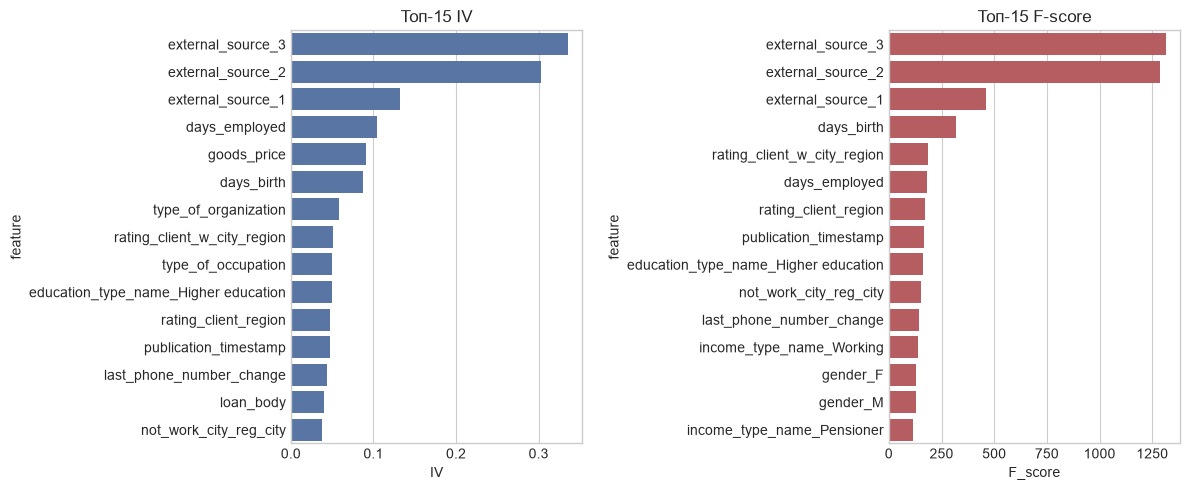

In [12]:
univariate = iv_table.merge(f_table, on='feature')
univariate['rank_IV'] = univariate['IV'].rank(ascending=False, method='min')
univariate['rank_F'] = univariate['F_score'].rank(ascending=False, method='min')
univariate = univariate.sort_values(['rank_IV', 'rank_F'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=iv_table.head(15), y='feature', x='IV', ax=axes[0], color='#4c72b0')
axes[0].set_title('Топ-15 IV')
sns.barplot(data=f_table.head(15), y='feature', x='F_score', ax=axes[1], color='#c44e52')
axes[1].set_title('Топ-15 F-score')
plt.tight_layout()
plt.show()


## 5. Пул признаков `*_stage_2`

Для каждого кандидата `n` из `TOP_N_OPTIONS`:

1. берём топ-\(n\) IV и топ-\(n\) F-score;
2. объединяем;
3. учим простой логрег на train, смотрим Gini на **val**.

Победивший набор переименовываем с постфиксом `_stage_2` — дальше работают только эти колонки.


In [13]:


# # сколько брать из топа IV и из топа F-score (один гиперпараметр, проверяем на val)
# TOP_N_OPTIONS = [20, 35, 50]

def union_top(n):
    """Топ-n по IV + топ-n по F-score, без повторов."""
    cols = iv_table['feature'].head(n).tolist()
    for col in f_table['feature'].head(n):
        if col not in cols:
            cols.append(col)
    return cols


n_search_rows = []
for n in TOP_N_OPTIONS:
    cols = union_top(n)
    Xtr = X_train_raw[cols]
    Xva = X_val_raw[cols]

    model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    model.fit(Xtr, y_train)
    gini_val = gini_score(y_val, model.predict_proba(Xva)[:, 1])

    n_search_rows.append({'n': n, 'union': len(cols), 'gini_val': gini_val})
    print(f'n={n}, признаков={len(cols)}, Gini val={gini_val:.4f}')

n_search = pd.DataFrame(n_search_rows)
best_n = int(n_search.loc[n_search['gini_val'].idxmax(), 'n'])
print('Лучший n:', best_n)
display(n_search)


n=20, признаков=26, Gini val=0.4588
n=35, признаков=45, Gini val=0.4584
n=50, признаков=63, Gini val=0.4588
Лучший n: 50


,n,union,gini_val
0,20,26,0.459
1,35,45,0.458
2,50,63,0.459


,n,union,gini_val
0,20,25,0.463
1,35,44,0.478
2,50,58,0.479


In [14]:
features_stage_2 = union_top(best_n)
rename_map = {c: f'{c}_stage_2' for c in features_stage_2}

print(f'Пул stage_2: {len(features_stage_2)} признаков (union топ-{best_n} IV и топ-{best_n} F-score)')
print('Из них только в IV:', sorted(set(iv_table['feature'].head(best_n)) - set(f_table['feature'].head(best_n))))
print('Из них только в F: ', sorted(set(f_table['feature'].head(best_n)) - set(iv_table['feature'].head(best_n))))

X_train = X_train_raw[features_stage_2].rename(columns=rename_map)
X_val = X_val_raw[features_stage_2].rename(columns=rename_map)
X_test = X_test_raw[features_stage_2].rename(columns=rename_map)
X_late = X_late_raw[features_stage_2].rename(columns=rename_map)

print('Колонки для моделей:', list(X_train.columns)[:12], '...')

X_train_sc = X_train.to_numpy()
X_val_sc = X_val.to_numpy()
X_test_sc = X_test.to_numpy()
X_late_sc = X_late.to_numpy()
print('Размер для моделей (train):', X_train_sc.shape)


Пул stage_2: 63 признаков (union топ-50 IV и топ-50 F-score)
Из них только в IV: ['annuity_payment', 'average_basementarea', 'average_entrance_count', 'average_years_beginexpluatation', 'median_basementarea', 'median_entrance_count', 'median_years_beginexpluatation', 'mode_basementarea', 'mode_entrance_count', 'mode_land_area', 'mode_years_beginexpluatation', 'non_living_area_avg', 'type_of_occupation']
Из них только в F:  ['children_count', 'contract_type_name_Cash loans', 'contract_type_name_Revolving loans', 'document_6_flag', 'family_status_name_Single / not married', 'hour_of_approval_process_start', 'housing_type_name_House / apartment', 'housing_type_name_Rented apartment', 'housing_type_name_With parents', 'living_city_not_work_city_flag', 'phone_flag', 'social_circle_defaults_30_days', 'social_circle_defaults_60_days']
Колонки для моделей: ['external_source_3_stage_2', 'external_source_2_stage_2', 'external_source_1_stage_2', 'days_employed_stage_2', 'goods_price_stage_2', 'da

## 6. Три модели и сетка гиперпараметров (Optuna GridSampler)

Это **полный перебор сетки**, только через Optuna (`GridSampler`), а не `GridSearchCV`.
Отличие важное: качество считаем на **готовой val**, а не кросс-валидацией внутри train.

Для каждой модели задайте словарь сетки, перезапустите ячейку — Optuna переберёт все комбинации.


In [15]:
def run_optuna_grid(name: str, search_space: dict, make_model, X_tr, y_tr, X_va, y_va):
    """Полный перебор search_space. make_model(params) -> sklearn-классификатор."""

    def objective(trial: optuna.Trial) -> float:
        params = {key: trial.suggest_categorical(key, values) for key, values in search_space.items()}
        model = make_model(params)
        model.fit(X_tr, y_tr)
        proba = model.predict_proba(X_va)[:, 1]
        return gini_score(y_va, proba)

    n_trials = int(np.prod([len(v) for v in search_space.values()]))
    sampler = GridSampler(search_space)
    study = optuna.create_study(direction='maximize', sampler=sampler, study_name=name)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f'{name}: лучший Gini val = {study.best_value:.4f}')
    print('  параметры:', study.best_params)
    return study


In [16]:
# Крутилки сеток: меняйте списки, затем перезапустите подбор.

LOGREG_GRID = {
    'C': [0.1, 1.0, 10.0],
    'class_weight': [None, 'balanced'],
}

KNN_GRID = {
    'n_neighbors': [15, 41],
    'weights': ['uniform', 'distance'],
}

RF_GRID = {
    'n_estimators': [100, 200],
    'max_depth': [8, 16],
    'min_samples_leaf': [20, 50],
    'class_weight': ['balanced'],
}


def make_logreg(p):
    return LogisticRegression(
        C=p['C'], class_weight=p['class_weight'],
        penalty='l2', solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE,
    )


def make_knn(p):
    return KNeighborsClassifier(
        n_neighbors=p['n_neighbors'], weights=p['weights'], n_jobs=-1,
    )


def make_rf(p):
    return RandomForestClassifier(
        n_estimators=p['n_estimators'], max_depth=p['max_depth'],
        min_samples_leaf=p['min_samples_leaf'], class_weight=p['class_weight'],
        n_jobs=-1, random_state=RANDOM_STATE,
    )


In [17]:
study_logreg = run_optuna_grid('logreg', LOGREG_GRID, make_logreg, X_train_sc, y_train, X_val_sc, y_val)
study_knn = run_optuna_grid('knn', KNN_GRID, make_knn, X_train_sc, y_train, X_val_sc, y_val)
study_rf = run_optuna_grid('random_forest', RF_GRID, make_rf, X_train_sc, y_train, X_val_sc, y_val)


logreg: лучший Gini val = 0.4610
  параметры: {'C': 0.1, 'class_weight': None}
knn: лучший Gini val = 0.3135
  параметры: {'n_neighbors': 41, 'weights': 'distance'}
random_forest: лучший Gini val = 0.4620
  параметры: {'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 50, 'class_weight': 'balanced'}


knn: лучший Gini val = 0.3906
  параметры: {'n_neighbors': 41, 'weights': 'distance'}


random_forest: лучший Gini val = 0.4740
  параметры: {'n_estimators': 100, 'max_depth': 16, 'min_samples_leaf': 50, 'class_weight': 'balanced'}


## 7. Сравнение моделей и инференс на test

Лучшую модель выбираем по Gini на val. Тест — один раз, без повторного кручения сеток.


In [15]:
makers = {'logreg': make_logreg, 'knn': make_knn, 'random_forest': make_rf}
studies = {'logreg': study_logreg, 'knn': study_knn, 'random_forest': study_rf}

fitted = {}
rows = []
for name, study in studies.items():
    model = makers[name](study.best_params)
    model.fit(X_train_sc, y_train)
    fitted[name] = model
    proba_tr = model.predict_proba(X_train_sc)[:, 1]
    proba_va = model.predict_proba(X_val_sc)[:, 1]
    proba_te = model.predict_proba(X_test_sc)[:, 1]
    rows.append({
        'model': name,
        'params': study.best_params,
        'Gini train': gini_score(y_train, proba_tr),
        'Gini val': gini_score(y_val, proba_va),
        'Gini test': gini_score(y_test, proba_te),
    })

compare = pd.DataFrame(rows).set_index('model').sort_values('Gini val', ascending=False)
print('Сравнение по Gini (модель выбрана по val):')
display(compare.drop(columns=['params']))
print('\nЛучшие параметры:')
for name, row in compare.iterrows():
    print(f'  {name}: {row["params"]}')

best_model_name = compare.index[0]
best_model = fitted[best_model_name]
proba_train = best_model.predict_proba(X_train_sc)[:, 1]
proba_val = best_model.predict_proba(X_val_sc)[:, 1]
proba_test = best_model.predict_proba(X_test_sc)[:, 1]
print(f'\nПобедитель: {best_model_name}  |  Gini test = {gini_score(y_test, proba_test):.4f}')


Сравнение по Gini (модель выбрана по val):


,Gini train,Gini val,Gini test
model,,,
logreg,0.489,0.479,0.473
random_forest,0.752,0.474,0.471
knn,1.000,0.391,0.383



Лучшие параметры:
  logreg: {'C': 10.0, 'class_weight': None}
  random_forest: {'n_estimators': 100, 'max_depth': 16, 'min_samples_leaf': 50, 'class_weight': 'balanced'}
  knn: {'n_neighbors': 41, 'weights': 'distance'}

Победитель: logreg  |  Gini test = 0.4727


## 8. Калибровка лучшей модели: подбор порога

Как в v1. Gini порог не меняет. После порога смотрим **F1** по дефолту.
Порог подбираем на val, применяем к test.


In [16]:
thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
thr_table = pd.DataFrame([classification_at_threshold(y_val, proba_val, t) for t in thresholds]).set_index('threshold')
print(f'Пороги для {best_model_name} на val:')
display(thr_table.style.format('{:.3f}').background_gradient(subset=['F1'], cmap='YlGn'))

best_threshold = float(thr_table['F1'].idxmax())
print(f'\nЛучший порог по F1 на val: {best_threshold:.2f}  (F1 = {thr_table.loc[best_threshold, "F1"]:.3f})')


Пороги для logreg на val:


,F1,Precision,Recall
threshold,,,
0.100000,0.272,0.177,0.584
0.150000,0.281,0.223,0.382
0.200000,0.264,0.271,0.257
0.250000,0.216,0.308,0.166
0.300000,0.156,0.349,0.100
0.350000,0.107,0.396,0.062
0.400000,0.066,0.454,0.035
0.450000,0.038,0.519,0.020
0.500000,0.018,0.559,0.009



Лучший порог по F1 на val: 0.15  (F1 = 0.281)


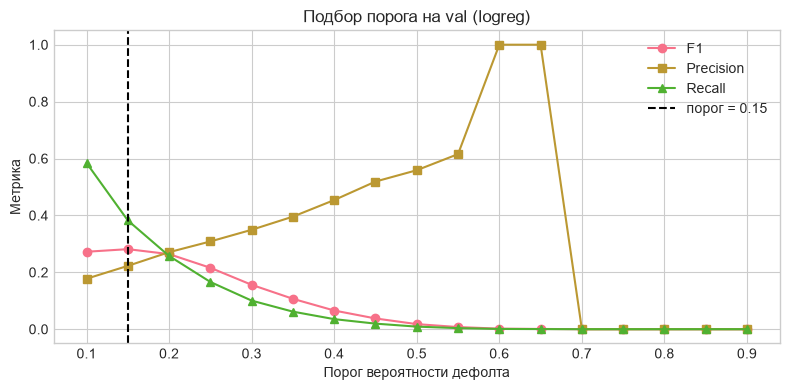

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr_table.index, thr_table['F1'], marker='o', label='F1')
ax.plot(thr_table.index, thr_table['Precision'], marker='s', label='Precision')
ax.plot(thr_table.index, thr_table['Recall'], marker='^', label='Recall')
ax.axvline(best_threshold, color='black', linestyle='--', label=f'порог = {best_threshold:.2f}')
ax.set_xlabel('Порог вероятности дефолта')
ax.set_ylabel('Метрика')
ax.set_title(f'Подбор порога на val ({best_model_name})')
ax.legend()
plt.tight_layout()
plt.show()


Test при пороге, выбранном на val:


  модель     logreg
  Gini      0.4727   (от порога не зависит)
  F1        0.2921
  Precision 0.2319
  Recall    0.3945


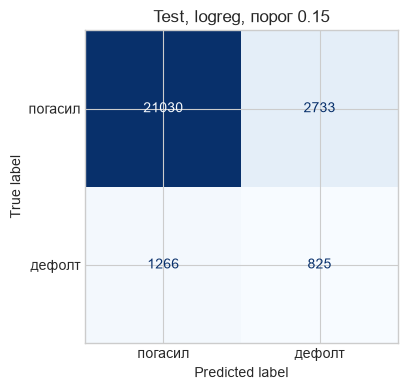

In [18]:
test_at_thr = classification_at_threshold(y_test, proba_test, best_threshold)
print('Test при пороге, выбранном на val:')
print(f'  модель     {best_model_name}')
print(f'  Gini      {gini_score(y_test, proba_test):.4f}   (от порога не зависит)')
print(f'  F1        {test_at_thr["F1"]:.4f}')
print(f'  Precision {test_at_thr["Precision"]:.4f}')
print(f'  Recall    {test_at_thr["Recall"]:.4f}')

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, (proba_test >= best_threshold).astype(int)),
    display_labels=['погасил', 'дефолт'],
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Test, {best_model_name}, порог {best_threshold:.2f}')
plt.tight_layout()
plt.show()


## 9. Late test

Ни сетку, ни порог, ни `n` для топов здесь больше не трогаем.


In [19]:
proba_late = best_model.predict_proba(X_late_sc)[:, 1]
late_at_thr = classification_at_threshold(y_late, proba_late, best_threshold)

print('Late test:')
print(f'  модель     {best_model_name}')
print(f'  Gini      {gini_score(y_late, proba_late):.4f}')
print(f'  F1        {late_at_thr["F1"]:.4f}   (порог {best_threshold:.2f}, выбран на val)')
print(f'  Precision {late_at_thr["Precision"]:.4f}')
print(f'  Recall    {late_at_thr["Recall"]:.4f}')


Late test:
  модель     logreg
  Gini      0.4910
  F1        0.3009   (порог 0.15, выбран на val)
  Precision 0.2385
  Recall    0.4077


In [20]:
summary = pd.DataFrame([
    {
        'split': 'train (сэмпл)',
        'n': len(y_train),
        'Gini': gini_score(y_train, proba_train),
        'F1': classification_at_threshold(y_train, proba_train, best_threshold)['F1'],
    },
    {
        'split': 'val',
        'n': len(y_val),
        'Gini': gini_score(y_val, proba_val),
        'F1': classification_at_threshold(y_val, proba_val, best_threshold)['F1'],
    },
    {
        'split': 'test',
        'n': len(y_test),
        'Gini': gini_score(y_test, proba_test),
        'F1': test_at_thr['F1'],
    },
    {
        'split': 'late_test',
        'n': len(y_late),
        'Gini': gini_score(y_late, proba_late),
        'F1': late_at_thr['F1'],
    },
]).set_index('split')

print(f'Сводка версии 2  |  модель: {best_model_name}  |  n топов: {best_n}  |  признаков stage_2: {len(features_stage_2)}')
summary


Сводка версии 2  |  модель: logreg  |  n топов: 50  |  признаков stage_2: 58


,n,Gini,F1
split,,,
train (сэмпл),50000,0.489,0.294
val,25853,0.479,0.281
test,25854,0.473,0.292
late_test,25853,0.491,0.301


### Что запомнить из v2

1. Сплиты те же, что в v1; новые признаки считаются одинаково на всех четырёх выборках.
2. Пропуски, One-Hot / Ordinal и scaler — до отбора, как в v1; fit только на train.
3. IV — через `BinningProcess`, F-score — через `SelectKBest`; `n` для топов проверяем логрегом на val.
4. Дальше живут только колонки с постфиксом `_stage_2`.
5. Сетка гиперпараметров — Optuna `GridSampler`, метрика — Gini на val.
6. Порог и late_test — как в v1, но уже у победившей модели.
